In [1]:
import sys
from pathlib import Path

import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

this_path = Path(__file__) if '__file__' in globals() else Path("<unknown>.ipynb").resolve()
work_path = next((p for p in this_path.parents if p.name == "research"), None)
tools_path = work_path / Path("../torch-tools")
sys.path.append(str(tools_path))

from exp_manager import cat_results, ExpManager
import pl_utils


In [2]:
em = ExpManager(this_path.parent)
df_base = em.fetch_results()

nested_columns = [name for name, dtype in zip(df_base.columns, df_base.dtypes) if dtype.is_nested()]
df_base = df_base.with_columns([pl.col(name).list.last().alias(f"{name}") for name in nested_columns])

# display(df_base)

Failed to save aggregated results: cannot cast List type (inner: 'Float64', to: 'String')


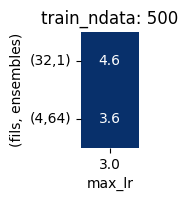

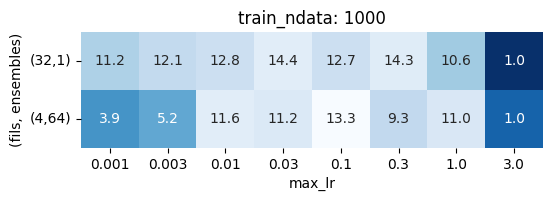

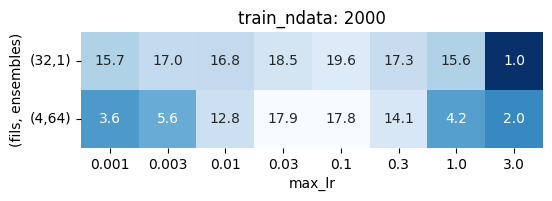

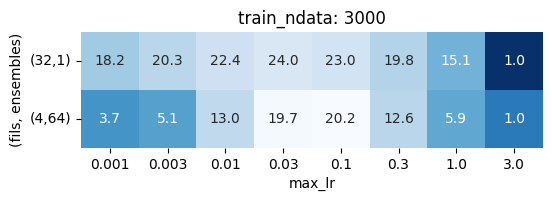

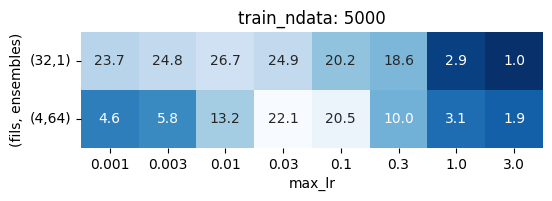

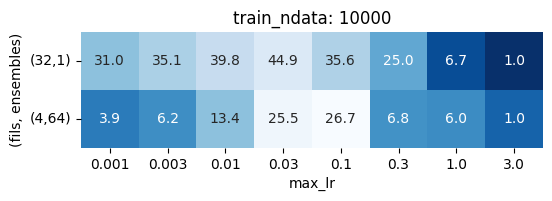

In [3]:
df = df_base

# df = df.filter(pl.col("fils").is_in([32, 16, 8, 4]))

piv_values = ["val_acc"] # 表示する値
piv_index = ["fils", "ensembles"] # 縦軸
piv_on = "max_lr" # 横軸

# agg = "len"
agg = "mean"

ext_column = "train_ndata" # このカラムの要素ごとにheatmapを表示

ext_l = df[ext_column].unique()
for ext in ext_l:
    # pivot table 作成
    df_ext = df.filter(pl.col(ext_column) == ext)
    df_piv = df_ext.pivot(values=piv_values, index=piv_index, on=piv_on, sort_columns=True, aggregate_function=agg)

    # カラムが文字列順になっているため、数字部分をソート
    _num_columns = sorted(int(x) for x in df_piv.columns if x.isdigit())
    new_columns = [str(_num_columns.pop(0)) if x.isdigit() else x for x in df_piv.columns]
    df_piv = df_piv.select(new_columns)

    # (fil, ensemble) の形式に
    df_piv = df_piv.with_columns(("(" + pl.col("fils").cast(pl.String) + "," + pl.col("ensembles").cast(pl.String)).alias("(fils, ensembles)") + ")")
    df_piv = df_piv.select(["(fils, ensembles)"] + new_columns).select(pl.exclude(["fils", "ensembles"]))

    # 0列目がx軸ラベル、1列目以降がy軸ラベルになる df を heat map に変換
    square_size = 0.75
    hm_x = df_piv.columns[1:]
    hm_y = df_piv[df_piv.columns[0]]
    data = df_piv.select(hm_x).to_numpy()
    annot = data.copy()

    # 正規化の方向を設定
    axis = 1    # 0: 行方向, 1: 列方向

    # min-max 正規化
    # min_vals = data.min(axis=axis, keepdims=True)
    # max_vals = data.max(axis=axis, keepdims=True)
    # data = (data - min_vals) / (max_vals - min_vals + 1e-8)  # ゼロ除算対策
    
    # Zスコア正規化
    mean_vals = data.mean(axis=axis, keepdims=True)
    std_vals = data.std(axis=axis, keepdims=True)
    data = (data - mean_vals) / (std_vals + 1e-8)  # ゼロ除算対策

    annot *= 100

    # sns.set_theme(style="whitegrid", font="Lato-light")
    sp_kwargs = {}
    hm_kwargs = {"cmap": "Blues_r", "cbar": False, "fmt": ".1f", "annot_kws": {"size": 10}}
    
    # plot
    fig, ax = plt.subplots(figsize=(len(hm_x)*square_size, len(hm_y)*square_size), **sp_kwargs)
    ax = sns.heatmap(data, annot=annot, square=True, **hm_kwargs)

    # memo
    # xticklabels=pl.Series(df_piv_val.columns)
    # xticklabels=pl.Series(df_piv_val.columns).str.head(4)

    ax.set_title(f"{ext_column}: {ext}", fontsize=12)
    ax.set_xlabel(piv_on, fontsize=10)
    ax.set_ylabel(hm_y.name, fontsize=10, rotation=90)
    ax.set_xticklabels(hm_x, fontsize=10, rotation=0)
    ax.set_yticklabels(hm_y, fontsize=10, rotation=0)
    plt.show()


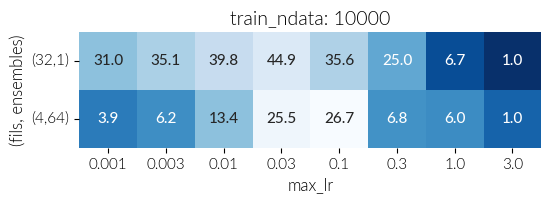

In [4]:

fig, ax = plt.subplots(figsize=(len(hm_x)*square_size, len(hm_y)*square_size))

fontname = "Lato"
fontweight = 300  # ここで整数のweightを指定

hm_kwargs = {
    "cmap": "Blues_r",
    "cbar": False,
    "fmt": ".1f",
    "annot_kws": {"size": 11, "fontname": fontname, "fontweight": 500}
}

ax = sns.heatmap(data, annot=annot, square=True, **hm_kwargs)

ax.set_title(f"{ext_column}: {ext}", fontsize=14, fontname=fontname, fontweight=fontweight)
ax.set_xlabel(piv_on, fontsize=12, fontname=fontname, fontweight=fontweight)
ax.set_ylabel(hm_y.name, fontsize=12, rotation=90, fontname=fontname, fontweight=fontweight)

ax.set_xticklabels(hm_x, fontsize=11, rotation=0)
for label in ax.get_xticklabels():
    label.set_fontname(fontname)
    label.set_fontweight(fontweight)

ax.set_yticklabels(hm_y, fontsize=11, rotation=0)
for label in ax.get_yticklabels():
    label.set_fontname(fontname)
    label.set_fontweight(fontweight)

plt.show()

In [5]:
import matplotlib.font_manager as fm
from matplotlib import font_manager

font_list = fm.fontManager.ttflist
font_names = sorted({f.name for f in font_list})
print(font_names)

search = "Lato"
fonts = [f for f in font_manager.fontManager.ttflist if search in f.name]
for f in fonts:
    print(f"Name: {f.name}, Style: {f.style}, Weight: {f.weight}, File: {f.fname}")


['Abyssinica SIL', 'Ani', 'AnjaliOldLipi', 'C059', 'Chandas', 'Chilanka', 'D050000L', 'DejaVu Math TeX Gyre', 'DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Dhurjati', 'Droid Sans Fallback', 'Dyuthi', 'FreeMono', 'FreeSans', 'FreeSerif', 'Gargi', 'Garuda', 'Gayathri', 'Gidugu', 'Gubbi', 'Gurajada', 'Jamrul', 'KacstArt', 'KacstBook', 'KacstDecorative', 'KacstDigital', 'KacstFarsi', 'KacstLetter', 'KacstNaskh', 'KacstOffice', 'KacstOne', 'KacstPen', 'KacstPoster', 'KacstQurn', 'KacstScreen', 'KacstTitle', 'KacstTitleL', 'Kalapi', 'Kalimati', 'Karumbi', 'Keraleeyam', 'Khmer OS', 'Khmer OS System', 'Kinnari', 'LKLUG', 'LakkiReddy', 'Laksaman', 'Latin Modern Math', 'Latin Modern Mono', 'Latin Modern Mono Caps', 'Latin Modern Mono Light', 'Latin Modern Mono Light Cond', 'Latin Modern Mono Prop', 'Latin Modern Mono Prop Light', 'Latin Modern Mono Slanted', 'Latin Modern Roman', 'Latin Modern Roman Caps', 'Latin Modern Roman Demi', 'Latin Mod